# Preliminary calibrated $\pi^0$ cross sections: x36_4, x36_5_407, and joint fit

**Preliminary — Hall C NPS analysis — provenance snapshot: 2026-10-06**

This notebook presents the frozen calibrated individual extractions for x36_4 and
x36_5_407, their simultaneous LH2 joint M0 fit, and the stored two-setting T/L
separation. It reads existing extraction products only; it does **not** rerun event
production, cross-section extraction, fits, or toy campaigns.

The producer convention is

$$2\pi\,\frac{d^2\sigma}{dt\,d\phi}=
\sigma_U+\sqrt{2\epsilon(1+\epsilon)}\,\sigma_{LT}\cos\phi
+\epsilon\,\sigma_{TT}\cos 2\phi,$$

with $\sigma_U=\sigma_T+\epsilon\sigma_L$. Cross sections are in nb/GeV$^2$.
Individual releases are frozen constrained additive-weight M0 fits. The joint fit has
per-setting U normalization/slope, shared LT/TT parameters, and fitted low-$-t'$ feed-in
terms. The statistical radius is
$\delta_{68}=Q_{0.68}(|z_{\rm toy}-z_{\rm truth}|)$, not an assumed Gaussian standard
deviation.

Selection conventions differ and are kept distinct: individual fits use the stored
$0.8\leq M_X\leq1.1$ GeV window, while the joint fit uses the combined-data
two-dimensional ellipse flag. Both use the same rectangular limits intersected with
the exact four-vertex $(x_B,Q^2)$ diamond. “Before selection” below means all records
in the combined physics tree; upstream reconstruction/PID cuts have already occurred.


In [37]:
from pathlib import Path
import hashlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon, Rectangle
from IPython.display import display
import uproot

warnings.filterwarnings("ignore", message="A NumPy version.*is required for this version of SciPy")
from scipy.stats import chi2 as chi2_distribution

REPO=Path("/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main")
OUTPUT_DIR=REPO/"output/publication_figures/x36_4_x36_5_407_calibrated"
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
KIN_ORDER=["KinC_x36_5_407","KinC_x36_4"]
KIN_SHORT={"KinC_x36_5_407":"x36_5_407","KinC_x36_4":"x36_4"}
COLORS={"KinC_x36_5_407":"#D55E00","KinC_x36_4":"#0072B2"}
MARKERS={"KinC_x36_5_407":"^","KinC_x36_4":"o"}
COMPONENT_LABEL={"U":r"$\sigma_U$","LT":r"$\sigma_{LT}$","TT":r"$\sigma_{TT}$"}
FIGURE_RECORDS=[]

mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":320,"font.size":9,
 "axes.labelsize":10,"axes.titlesize":10,"legend.fontsize":8,"xtick.labelsize":8,
 "ytick.labelsize":8,"axes.linewidth":0.8,"lines.linewidth":1.4,"lines.markersize":5.5,
 "xtick.direction":"in","ytick.direction":"in","xtick.top":True,"ytick.right":True,
 "axes.grid":False,"pdf.fonttype":42,"ps.fonttype":42})

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()

def load_json(path):
    path=Path(path)
    if not path.is_file(): raise FileNotFoundError(f"Missing JSON: {path}")
    return json.loads(path.read_text())

def load_csv(path,required,unique=None):
    path=Path(path)
    if not path.is_file(): raise FileNotFoundError(f"Missing CSV: {path}")
    df=pd.read_csv(path); missing=sorted(set(required)-set(df.columns))
    if missing: raise ValueError(f"{path}: missing columns {missing}")
    if df.empty: raise ValueError(f"{path}: empty table")
    if unique and df.duplicated(list(unique)).any(): raise ValueError(f"{path}: duplicate key {unique}")
    return df

def require_finite(df,columns,label):
    a=df[list(columns)].apply(pd.to_numeric,errors="coerce").to_numpy(float)
    if not np.isfinite(a).all(): raise ValueError(f"{label}: non-finite values in {columns}")

def preliminary(ax):
    fig=ax.figure
    fig.text(.02,.955,r"$\mathbf{NPS\ RG1a}\ \mathit{Preliminary}$",
             transform=fig.transFigure,ha="left",va="center",
             color="black",fontsize=12.5,clip_on=False,zorder=30)
    fig._has_preliminary_label=True

def export_figure(fig,stem,description):
    if getattr(fig,"_has_preliminary_label",False):
        fig.subplots_adjust(top=min(fig.subplotpars.top,.89))
    pdf=OUTPUT_DIR/f"{stem}.pdf"; png=OUTPUT_DIR/f"{stem}.png"
    fig.savefig(pdf,bbox_inches="tight",metadata={"Title":description,"Creator":"plot_xsec_x36_4_x36_5_407.ipynb"})
    fig.savefig(png,dpi=320,bbox_inches="tight")
    FIGURE_RECORDS.append({"figure":stem,"PDF":str(pdf.relative_to(REPO)),
                           "PNG":str(png.relative_to(REPO)),"shows":description})
    display(fig); plt.close(fig)

def ordered_matrix(df):
    labels=df.iloc[:,0].astype(str).tolist()
    if labels!=list(df.columns[1:]): raise ValueError("Matrix labels differ")
    a=df.iloc[:,1:].to_numpy(float)
    if a.shape!=(len(labels),len(labels)) or not np.isfinite(a).all(): raise ValueError("Invalid matrix")
    return labels,a

print("Repository:",REPO)
print("Figure output:",OUTPUT_DIR)

Repository: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main
Figure output: /w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/publication_figures/x36_4_x36_5_407_calibrated


## Immutable input manifest

Every consumed file is verified against this pre-implementation SHA-256 manifest before
loading and again after all exports. Paths are repository-relative. ROOT files are read
with uproot; no ROOT macro is executed.


In [38]:
INPUTS={
"src/xsec_extract/xsec_config/xsec_config_x36_4.json":("055a75e2d4d494cb618b1fa38a3ea0c86cce4f85117bdb61e029980d2988baa2","x36_4 cuts/binning"),
"src/xsec_extract/xsec_config/xsec_config_x36_5_407.json":("22ecb70d5130a6b6e2eca64d8d4aa136648600e00be3eb54fdf36ff54777a1dd","x36_5_407 cuts/binning"),
"output/KinC_x36_4/xsec_calibrated/preliminary_cross_sections_calibrated.csv":("e02ce021695f378ab17ee9c055b5a3d6c5b6a8e1b9d5496655b22cc47454c7c0","x36_4 responses"),
"output/KinC_x36_4/xsec_calibrated/published_covariance_calibrated68.csv":("b4c8e372d1af87943a7cac7c5d1354dcf1c8c0f323c51afb6232ae8d15c4b10e","x36_4 calibrated response covariance representation"),
"output/KinC_x36_4/xsec_calibrated/toy_residual_statistics.csv":("c3940b17731fb6852241d34aa2eeff52c08050a0496e736bc1c2f80ad174d192","x36_4 interval/calibration diagnostics"),
"output/KinC_x36_4/xsec_calibrated/bin_statistics.csv":("a86599c2849ceabf27d7850c8c062ae7ad7c9a41540bb47a247e435d69b22f01","x36_4 weighted occupancy"),
"output/KinC_x36_4/xsec_calibrated/calibration_summary.json":("898694aaf2069c3415f699773eec35f02fd48ebcdbc35e5d1bf0e9259ac912d1","x36_4 fit status"),
"output/KinC_x36_5_407/xsec_calibrated/preliminary_cross_sections_calibrated.csv":("445bebdca384563ff56833ad486a59567204fedf676deb3d207a9ac55b861885","x36_5_407 responses"),
"output/KinC_x36_5_407/xsec_calibrated/published_covariance_calibrated68.csv":("34fdac4b6287af1ec0d1df3f348d67a940c30dbde04b137501fb36ef8cb9ff9b","x36_5_407 calibrated response covariance representation"),
"output/KinC_x36_5_407/xsec_calibrated/toy_residual_statistics.csv":("5b2c682f87bd962b35dc5bcf491ebb0fcfb30a827405a5a83cbc2c8243575539","x36_5_407 interval/calibration diagnostics"),
"output/KinC_x36_5_407/xsec_calibrated/bin_statistics.csv":("2a18fd763c3b4ae9ed9070e4c46d97e90983f1d37eda212f37543ffe159612a1","x36_5_407 weighted occupancy"),
"output/KinC_x36_5_407/xsec_calibrated/calibration_summary.json":("39d18c45fb54514d5a2a2975759b3781771394964b3908f47fa4c0a042854c8c","x36_5_407 fit status"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_preliminary_cross_sections_calibrated.csv":("18fd59369d467fd0e5a315a016bec4dee0f05988fb887943b85f33fd0bab7bd2","joint responses/systematic"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/published_covariance_calibrated68.csv":("b1bedb41dc379e3cf155d809045fb3c5e91c0ad305516b5df8b92eee0703d109","joint calibrated response covariance representation"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/toy_residual_statistics.csv":("08a686c5fa3598f2194cc068d6268c939e2f8bcc3225f35327b192dbb4802399","joint interval/calibration diagnostics"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/published_correlation_toy.csv":("88c200dc082bc17afe203c420e8878a0de46cdab59f30d85f124e028119d3831","joint response correlations"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_parameter_correlation_toy.csv":("d180da559d92e4e16a260eddc7bdb8c5eb3460dcad8552ee0e7d2adbb3820321","joint parameter correlations"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/calibration_summary.json":("5985b39a08319541087959e6e505adac9d29b13b7a724bf19a5a8d8cc2f19209","joint fit/toy status"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/joint_lt_separated_cross_sections.csv":("9f049672120ef4cb1aa47c38a2dc2487f5da7b066e4dc293db2eeacc7db9fa22","stored T/L responses"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/joint_lt_covariance_calibrated68.csv":("c4c2f2f194c432409c3b45364c27dde1409c51835c8a7b9e01198cfdcbf56725","T/L calibrated covariance representation"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/joint_lt_correlation_toy.csv":("820de32f25d99f1e13c88a0ec8663ed373f4dbc5db5abc678abedb8cb9f356ed","T/L correlations"),
"output/joint_x36_5_407_x36_4_LH2_calibrated/joint_lt_separation/calibration_summary.json":("4d0d64c7b438bd7f72d82e7157b72fe77fba1d68d4079d5c23d450b901c97ae9","T/L convention/epsilon"),
"output/joint_x36_5_407_x36_4_LH2/joint_manifest.json":("cfd4c67102c58dfc0859e945272963b9ca0085f4c5f2266cdaba0de0ebe01a3c","joint selection/bin contract"),
"output/joint_x36_5_407_x36_4_LH2/toy_campaigns/20261006T052846_1954381/central.json":("f6a21018637ff602a52b59d1fd2d3f19f7331d2afa720677f42de5e6e22fa4c6","frozen central metadata"),
"output/joint_x36_5_407_x36_4_LH2/toy_campaigns/20261006T052846_1954381/central.npz":("7c390dc6ec3f8bf871f75e9518af766f1236a584bb7f4226055843ef16517d69","frozen yields/prediction/covariance"),
"output/joint_x36_5_407_x36_4_LH2/toy_campaigns/20261006T052846_1954381/toys/replicas.npz":("ad62910f0d7fb888989c2bd734140087c585a2d6330e96366c81995a4ec3475d","500 accepted joint toys"),
"output/joint_x36_5_407_x36_4_LH2_inputs/KinC_x36_5_407/migration_reco_rows.csv":("37082c321b60526fb480ba23a1a5e1ec21b9ee3f49ca0c8fea8bc5b6a0660712","x36_5_407 phi-row coordinates"),
"output/joint_x36_5_407_x36_4_LH2_inputs/KinC_x36_4/migration_reco_rows.csv":("5f8e5c949c16fc7ae43315b02de6c1ef59d2daea13a00674db56aa271f6fd678","x36_4 phi-row coordinates"),
"output/KinC_x36_5_407/KinC_x36_5/root/combined_branches_LH2.root":("b6616c972878882afe2c513b80ce6fb31c42ed44ba67ebc62b863ee0cd8e3d10","x36_5_407 data phase space"),
"output/KinC_x36_4/root/combined_branches_LH2.root":("a406e48af8ea690f9de303e41787d7ae8b214fceae6b2a459a8be3999bbd6338","x36_4 data phase space")}
rows=[]
for rel,(expected,role) in INPUTS.items():
    got=sha256(REPO/rel)
    if got!=expected: raise RuntimeError(f"Checksum mismatch: {rel}")
    rows.append({"path":rel,"role":role,"sha256":got})
input_manifest=pd.DataFrame(rows)
display(input_manifest)
print(f"Verified {len(input_manifest)} immutable inputs before loading.")

,path,role,sha256
0,src/xsec_extract/xsec_config/xsec_config_x36_4...,x36_4 cuts/binning,055a75e2d4d494cb618b1fa38a3ea0c86cce4f85117bdb...
1,src/xsec_extract/xsec_config/xsec_config_x36_5...,x36_5_407 cuts/binning,22ecb70d5130a6b6e2eca64d8d4aa136648600e00be3eb...
2,output/KinC_x36_4/xsec_calibrated/preliminary_...,x36_4 responses,e02ce021695f378ab17ee9c055b5a3d6c5b6a8e1b9d549...
3,output/KinC_x36_4/xsec_calibrated/published_co...,x36_4 calibrated response covariance represent...,b4c8e372d1af87943a7cac7c5d1354dcf1c8c0f323c51a...
4,output/KinC_x36_4/xsec_calibrated/toy_residual...,x36_4 interval/calibration diagnostics,c3940b17731fb6852241d34aa2eeff52c08050a0496e73...
5,output/KinC_x36_4/xsec_calibrated/bin_statisti...,x36_4 weighted occupancy,a86599c2849ceabf27d7850c8c062ae7ad7c9a41540bb4...
6,output/KinC_x36_4/xsec_calibrated/calibration_...,x36_4 fit status,898694aaf2069c3415f699773eec35f02fd48ebcdbc35e...
7,output/KinC_x36_5_407/xsec_calibrated/prelimin...,x36_5_407 responses,445bebdca384563ff56833ad486a59567204fedf676deb...
8,output/KinC_x36_5_407/xsec_calibrated/publishe...,x36_5_407 calibrated response covariance repre...,34fdac4b6287af1ec0d1df3f348d67a940c30dbde04b13...
9,output/KinC_x36_5_407/xsec_calibrated/toy_resi...,x36_5_407 interval/calibration diagnostics,5b2c682f87bd962b35dc5bcf491ebb0fcfb30a827405a5...


Verified 30 immutable inputs before loading.


## Loaders, schemas, and analysis contracts

The exact diamond vertices are listed below in producer order. The accepted region is
the intersection of this polygon with $3.3\le Q^2\le4.7$ GeV$^2$,
$0.29\le x_B\le0.44$, $-0.7\le t'<0$ GeV$^2$, and finite wrapped $\phi$.
Bin 0 is the largest-$-t'$ bin; bin 4 is closest to the forward limit.


In [39]:
CFG_PATH={k:REPO/f"src/xsec_extract/xsec_config/xsec_config_{k.replace('KinC_','')}.json" for k in KIN_ORDER}
IND_DIR={k:REPO/f"output/{k}/xsec_calibrated" for k in KIN_ORDER}
JOINT_DIR=REPO/"output/joint_x36_5_407_x36_4_LH2_calibrated"
JOINT_RAW=REPO/"output/joint_x36_5_407_x36_4_LH2"
JOINT_INPUT=REPO/"output/joint_x36_5_407_x36_4_LH2_inputs"
ROOT_PATH={"KinC_x36_5_407":REPO/"output/KinC_x36_5_407/KinC_x36_5/root/combined_branches_LH2.root",
           "KinC_x36_4":REPO/"output/KinC_x36_4/root/combined_branches_LH2.root"}

configs={k:load_json(p) for k,p in CFG_PATH.items()}
joint_manifest=load_json(JOINT_RAW/"joint_manifest.json")
joint_summary=load_json(JOINT_DIR/"calibration_summary.json")
lt_summary=load_json(JOINT_DIR/"joint_lt_separation/calibration_summary.json")
individual_summary={k:load_json(IND_DIR[k]/"calibration_summary.json") for k in KIN_ORDER}
individual={}; individual_residual={}; bin_stats={}
for k in KIN_ORDER:
    individual[k]=load_csv(IND_DIR[k]/"preliminary_cross_sections_calibrated.csv",
      ["tprime_bin","tprime_low","tprime_high","response_weighted_tprime","sigma_U","U_delta68_stat",
       "sigma_LT","LT_delta68_stat","sigma_TT","TT_delta68_stat","units","status"],["tprime_bin"])
    individual_residual[k]=load_csv(IND_DIR[k]/"toy_residual_statistics.csv",
      ["quantity","component","tprime_bin","central","delta68","basic_interval_lower","basic_interval_upper",
       "use_basic_interval","toy_mean_bias","abs_bias_over_delta68","cross_validated_coverage68","units"],
      ["component","tprime_bin"])
    bin_stats[k]=load_csv(IND_DIR[k]/"bin_statistics.csv",
      ["tprime_bin","tprime_low","tprime_high","response_weighted_tprime","included_phi_rows",
       "effective_entries","relative_weighted_yield_error"],["tprime_bin"])

individual_cov={}
expected_individual_labels=[f"{c}(bin{b})" for c in ["U","LT","TT"] for b in range(5)]
for k in KIN_ORDER:
    labels,cov=ordered_matrix(pd.read_csv(IND_DIR[k]/"published_covariance_calibrated68.csv"))
    if labels!=expected_individual_labels: raise ValueError(f"{k}: unexpected covariance labels")
    individual_cov[k]=cov

joint=load_csv(JOINT_DIR/"joint_preliminary_cross_sections_calibrated.csv",
 ["setting_index","kinematic","component","truth_block","response_weighted_tprime","value","delta68_stat",
  "basic_interval_lower","basic_interval_upper","target_systematic","units","status"],
 ["kinematic","component","truth_block"])
joint_residual=load_csv(JOINT_DIR/"toy_residual_statistics.csv",
 ["quantity","central","toy_mean_bias","delta68","use_basic_interval","cross_validated_coverage68",
  "target_systematic_absolute","units"],["quantity"])
lt=load_csv(JOINT_DIR/"joint_lt_separation/joint_lt_separated_cross_sections.csv",
 ["quantity","component","tprime_bin","tprime_center","central","delta68_stat","basic_interval_lower",
  "basic_interval_upper","use_basic_interval","cross_validated_coverage68","toy_mean_bias",
  "target_scale_systematic","units"],["component","tprime_bin"])
published_labels,published_corr=ordered_matrix(pd.read_csv(JOINT_DIR/"published_correlation_toy.csv"))
joint_cov_labels,joint_cov68=ordered_matrix(pd.read_csv(JOINT_DIR/"published_covariance_calibrated68.csv"))
if joint_cov_labels!=published_labels: raise ValueError("Joint covariance/correlation labels differ")
parameter_labels,parameter_corr=ordered_matrix(pd.read_csv(JOINT_DIR/"joint_parameter_correlation_toy.csv"))
lt_labels,lt_corr=ordered_matrix(pd.read_csv(JOINT_DIR/"joint_lt_separation/joint_lt_correlation_toy.csv"))
lt_cov_labels,lt_cov68=ordered_matrix(pd.read_csv(JOINT_DIR/"joint_lt_separation/joint_lt_covariance_calibrated68.csv"))
assert lt_labels==lt_cov_labels

central_json=load_json(JOINT_RAW/"toy_campaigns/20261006T052846_1954381/central.json")
with np.load(JOINT_RAW/"toy_campaigns/20261006T052846_1954381/central.npz") as z:
    central={n:z[n].copy() for n in z.files}
with np.load(JOINT_RAW/"toy_campaigns/20261006T052846_1954381/toys/replicas.npz") as z:
    toys={n:z[n].copy() for n in z.files}

maps=[]
for setting,k in enumerate(KIN_ORDER):
    f=load_csv(JOINT_INPUT/k/"migration_reco_rows.csv",["reco_row","it","ip","phi_lo","phi_hi"],["reco_row"])
    f=f.sort_values("reco_row").reset_index(drop=True); f["setting_index"]=setting; f["kinematic"]=k; maps.append(f)
row_map=pd.concat(maps,ignore_index=True)
for n in ["y","prediction","variance","data_variance"]: row_map[n]=central[n]
row_map["phi_center"]=(row_map.phi_lo+row_map.phi_hi)/2
row_map["pull"]=(row_map.y-row_map.prediction)/np.sqrt(row_map.variance)
row_map["ratio"]=row_map.y/row_map.prediction
row_map["ratio_error"]=np.sqrt(row_map.variance)/row_map.prediction

branches=["event_id","run_number","Q2","xB","t","tmin","phi","mmiss_all","mpi0_all","is_exclusive_ellipse_combined"]
phase={}
for k,p in ROOT_PATH.items():
    with uproot.open(p) as f:
        missing=sorted(set(branches)-set(f["physics"].keys()))
        if missing: raise ValueError(f"{p}: missing branches {missing}")
        phase[k]=pd.DataFrame(f["physics"].arrays(branches,library="np"))
    phase[k]["tprime"]=phase[k].t.astype(float)-phase[k].tmin.astype(float)

diamond=np.asarray(joint_manifest["bins"]["diamond_xb_q2_vertices"],float)
tprime_edges=np.asarray(joint_manifest["bins"]["tprime_bin_edges"],float)
q2_edges=np.asarray(joint_manifest["bins"]["q2_bin_edges"],float)
xb_edges=np.asarray(joint_manifest["bins"]["xb_bin_edges_by_q2"][0],float)
phi_edges=np.asarray(joint_manifest["bins"]["phi_bin_edges"],float)

def inside_diamond(xb,q2):
    xb=np.asarray(xb,float); q2=np.asarray(q2,float)
    cross=np.array([(b[0]-a[0])*(q2-a[1])-(b[1]-a[1])*(xb-a[0])
                    for a,b in zip(diamond,np.roll(diamond,-1,axis=0))])
    return np.all(cross>=-1e-12,axis=0)|np.all(cross<=1e-12,axis=0)

def kinematic_mask(f):
    finite=np.isfinite(f[["Q2","xB","tprime","phi"]]).all(axis=1).to_numpy()
    return (finite & f.Q2.between(*q2_edges,inclusive="both").to_numpy()
      & f.xB.between(*xb_edges,inclusive="both").to_numpy()
      & f.tprime.between(tprime_edges[0],tprime_edges[-1],inclusive="left").to_numpy()
      & inside_diamond(f.xB,f.Q2))

selection_masks={}
for k,f in phase.items():
    c=configs[k]
    iw=f.mmiss_all.between(c["mmiss_lower_gev"],c["mmiss_upper_gev"],inclusive="both").to_numpy()
    je=f.is_exclusive_ellipse_combined.to_numpy()!=0
    selection_masks[k]={"individual_exclusive":iw,"joint_exclusive":je,
                        "individual_final":iw&kinematic_mask(f),"joint_final":je&kinematic_mask(f)}

vertices=pd.DataFrame(diamond,columns=["x_B","Q2_GeV2"],index=[f"V{i+1}" for i in range(4)])
display(vertices)
print("Individual selection:",{k:(configs[k]["mmiss_select"],configs[k]["mmiss_lower_gev"],configs[k]["mmiss_upper_gev"]) for k in KIN_ORDER})
print("Joint selection:",joint_manifest["selection"])

,x_B,Q2_GeV2
V1,0.285366,3.243862
V2,0.338223,3.619312
V3,0.439530,4.698466
V4,0.372148,4.244414


Individual selection: {'KinC_x36_5_407': ('window', 0.8, 1.1), 'KinC_x36_4': ('window', 0.8, 1.1)}
Joint selection: {'exclusive_selection': 'ellipse', 'sim_reconstructed_mass_selection': 'combined_data_geometry', 'mmiss_lower_gev': '0.59999999999999998', 'mmiss_upper_gev': '1.1000000000000001', 'target_contam_factor': '0.58399999999999996', 'target_contam_factor_err': '0.014'}


### Numerical validation before plotting

These assertions guard schemas, finiteness, nonnegative uncertainties, common binning,
point counts, fit status, campaign uniqueness, and dataset labels. Stored T/L values must
reproduce both joint sigma_U points to floating-point precision.


In [40]:
for k in KIN_ORDER:
    a=individual[k]; r=individual_residual[k]
    assert len(a)==5 and len(r)==15 and len(bin_stats[k])==5
    assert a.tprime_bin.tolist()==list(range(5))
    assert np.all(np.diff(a.tprime_low)>0) and np.all(a.tprime_low<a.tprime_high)
    require_finite(a,["response_weighted_tprime","sigma_U","U_delta68_stat","sigma_LT",
                      "LT_delta68_stat","sigma_TT","TT_delta68_stat"],k)
    assert (a[["U_delta68_stat","LT_delta68_stat","TT_delta68_stat"]]>=0).all().all()
    assert individual_summary[k]["status"]=="PRELIMINARY MODEL EXTRACTION READY"
    assert individual_summary[k]["accepted_toys"]==500 and configs[k]["mmiss_select"]=="window"
    np.testing.assert_allclose(individual_summary[k]["tprime_bin_edges"],tprime_edges,rtol=0,atol=0)
    np.testing.assert_allclose(configs[k]["diamond_xb_q2_vertices"],diamond,rtol=0,atol=0)
assert len(joint)==30 and set(joint.kinematic)==set(KIN_ORDER) and len(joint_residual)==30 and len(lt)==10
require_finite(joint,["response_weighted_tprime","value","delta68_stat","target_systematic"],"joint")
require_finite(lt,["tprime_center","central","delta68_stat","target_scale_systematic"],"T/L")
assert (joint[["delta68_stat","target_systematic"]]>=0).all().all()
assert (lt[["delta68_stat","target_scale_systematic"]]>=0).all().all()
assert joint_summary["publication_ready"] is True and joint_summary["accepted_toys"]==500
assert lt_summary["status"]=="PRELIMINARY MODEL-DEPENDENT T/L SEPARATION"
assert central_json["rank"]==10 and central_json["rows"]==120 and central_json["boundary"] is True
assert np.isfinite(central_json["condition"])
assert toys["pub"].shape==(500,30) and len(np.unique(toys["index"]))==500
assert np.all(toys["iterations"]>0) and toys["boundary_hit"].dtype==bool
assert len(row_map)==len(central["y"])==120
require_finite(row_map,["y","prediction","variance","pull","ratio","ratio_error"],"joint rows")
assert (row_map.prediction>0).all() and (row_map.variance>0).all()

value_lookup=dict(zip(central_json["published_names"],central_json["published"]))
mean_lookup=dict(zip(central_json["published_names"],central_json["means"]))
for r in joint.itertuples(index=False):
    n=f"{r.kinematic}:{r.component}(bin{r.truth_block})"
    np.testing.assert_allclose(r.value,value_lookup[n],rtol=2e-12,atol=2e-12)
    np.testing.assert_allclose(r.response_weighted_tprime,mean_lookup[n],rtol=2e-12,atol=2e-12)

epsilons={x["kinematic"]:float(x["epsilon"]) for x in lt_summary["settings"]}
for b in range(5):
    T=lt[(lt.component=="T")&(lt.tprime_bin==b)].iloc[0].central
    L=lt[(lt.component=="L")&(lt.tprime_bin==b)].iloc[0].central
    for k,e in epsilons.items():
        U=joint[(joint.kinematic==k)&(joint.component=="U")&(joint.truth_block==b)].iloc[0].value
        np.testing.assert_allclose(U,T+e*L,rtol=2e-12,atol=2e-12)
for k in KIN_ORDER:
    assert selection_masks[k]["individual_final"].sum()>0 and selection_masks[k]["joint_final"].sum()>0
    assert not np.array_equal(selection_masks[k]["individual_final"],selection_masks[k]["joint_final"])
    iu=individual[k].sigma_U.to_numpy()
    ju=joint[(joint.kinematic==k)&(joint.component=="U")].sort_values("truth_block").value.to_numpy()
    assert not np.array_equal(iu,ju)
print("All pre-plot validation assertions passed.")
print(f"Joint central fit: Q={central_json['objective']:.6f}, rows=120, rank=10, condition={central_json['condition']:.3f}, boundary={central_json['boundary']}")


All pre-plot validation assertions passed.
Joint central fit: Q=162.403517, rows=120, rank=10, condition=11.568, boundary=True


## Phase space, accepted region, and binning

Candidate panels show the combined-data tree before extraction selection. Individual panels
apply the missing-mass window and all phase-space limits; joint panels instead apply the
stored combined-ellipse decision and those limits. The solid polygon is the exact diamond;
the dashed rectangle is the nominal $Q^2$–$x_B$ bin. Density is raw candidate-record
occupancy, not an efficiency-corrected yield.


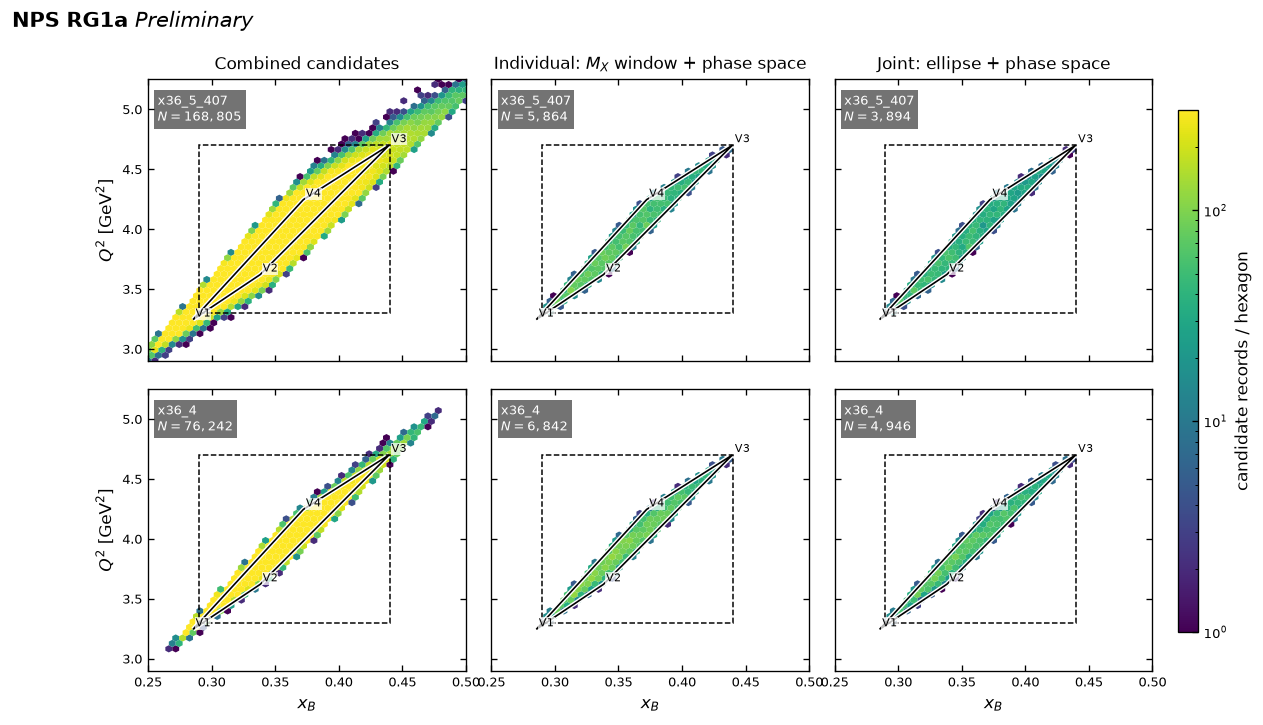

In [41]:
fig,axes=plt.subplots(2,3,figsize=(10.8,6.4),sharex=True,sharey=True)
specs=[("all","Combined candidates"),("individual_final",r"Individual: $M_X$ window + phase space"),
       ("joint_final","Joint: ellipse + phase space")]
for i,k in enumerate(KIN_ORDER):
    f=phase[k]
    for j,(name,title) in enumerate(specs):
        ax=axes[i,j]; take=np.ones(len(f),bool) if name=="all" else selection_masks[k][name]
        ax.hexbin(f.loc[take,"xB"],f.loc[take,"Q2"],gridsize=46,extent=(.25,.50,2.9,5.25),
                  mincnt=1,norm=LogNorm(vmin=1,vmax=300),cmap="viridis",linewidths=0)
        ax.add_patch(Polygon(diamond,closed=True,fill=False,edgecolor="white",lw=2.7,zorder=5))
        ax.add_patch(Polygon(diamond,closed=True,fill=False,edgecolor="black",lw=1,zorder=6))
        ax.add_patch(Rectangle((xb_edges[0],q2_edges[0]),np.diff(xb_edges)[0],np.diff(q2_edges)[0],
                               fill=False,edgecolor="black",lw=.9,ls="--",zorder=6))
        for n,(xb,q2) in enumerate(diamond):
            ax.text(xb+.002,q2+.025,f"V{n+1}",fontsize=6.5,
                    bbox={"fc":"white","ec":"none","alpha":.72,"pad":.4},zorder=7)
        ax.text(.03,.95,f"{KIN_SHORT[k]}\n$N={take.sum():,}$",transform=ax.transAxes,va="top",
                color="white",fontsize=8,bbox={"fc":"black","ec":"none","alpha":.55,"pad":2})
        if i==0: ax.set_title(title)
        ax.set_xlim(.25,.50); ax.set_ylim(2.9,5.25)
        if i==1: ax.set_xlabel(r"$x_B$")
        if j==0: ax.set_ylabel(r"$Q^2$ [GeV$^2$]")
fig.subplots_adjust(right=.90,wspace=.08,hspace=.10)
cax=fig.add_axes([.92,.16,.015,.68])
fig.colorbar(mpl.cm.ScalarMappable(norm=LogNorm(vmin=1,vmax=300),cmap="viridis"),cax=cax,
             label="candidate records / hexagon")
preliminary(axes[0,2])
export_figure(fig,"01_phase_space_selection","Data phase space before/after individual-window and joint-ellipse selections, with exact diamond")


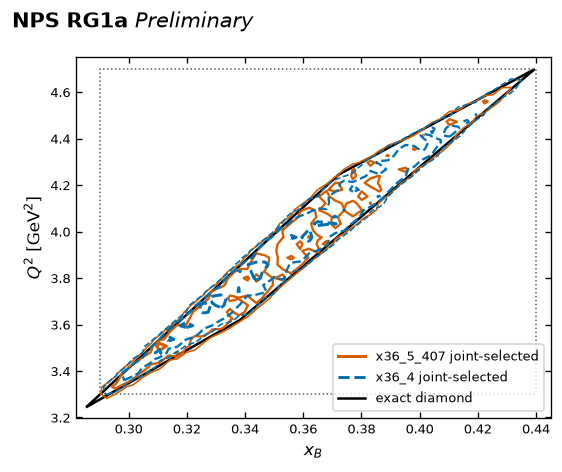

In [42]:
fig,ax=plt.subplots(figsize=(5.1,3.9))
xb_bins=np.linspace(.285,.445,54); q_bins=np.linspace(3.20,4.75,54)
for k,ls in zip(KIN_ORDER,["-","--"]):
    f=phase[k]; take=selection_masks[k]["joint_final"]
    h,xe,ye=np.histogram2d(f.loc[take,"xB"],f.loc[take,"Q2"],bins=(xb_bins,q_bins))
    h=h.T/max(h.max(),1)
    ax.contour((xe[:-1]+xe[1:])/2,(ye[:-1]+ye[1:])/2,h,levels=[.10,.35,.70],
               colors=[COLORS[k]],linestyles=ls,linewidths=[1,1.4,1.8])
ax.add_patch(Polygon(diamond,closed=True,fill=False,edgecolor="black",lw=1.5))
ax.add_patch(Rectangle((xb_edges[0],q2_edges[0]),np.diff(xb_edges)[0],np.diff(q2_edges)[0],
                       fill=False,edgecolor=".35",lw=.9,ls=":"))
ax.set(xlabel=r"$x_B$",ylabel=r"$Q^2$ [GeV$^2$]",xlim=(.282,.445),ylim=(3.20,4.75))
ax.legend(handles=[Line2D([0],[0],color=COLORS[KIN_ORDER[0]],lw=1.8,ls="-",label="x36_5_407 joint-selected"),
 Line2D([0],[0],color=COLORS[KIN_ORDER[1]],lw=1.8,ls="--",label="x36_4 joint-selected"),
 Line2D([0],[0],color="black",lw=1.5,label="exact diamond")],loc="lower right")
preliminary(ax)
export_figure(fig,"02_phase_space_overlap","Overlap of joint-selected x36_4 and x36_5_407 Q2-xB density contours")


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


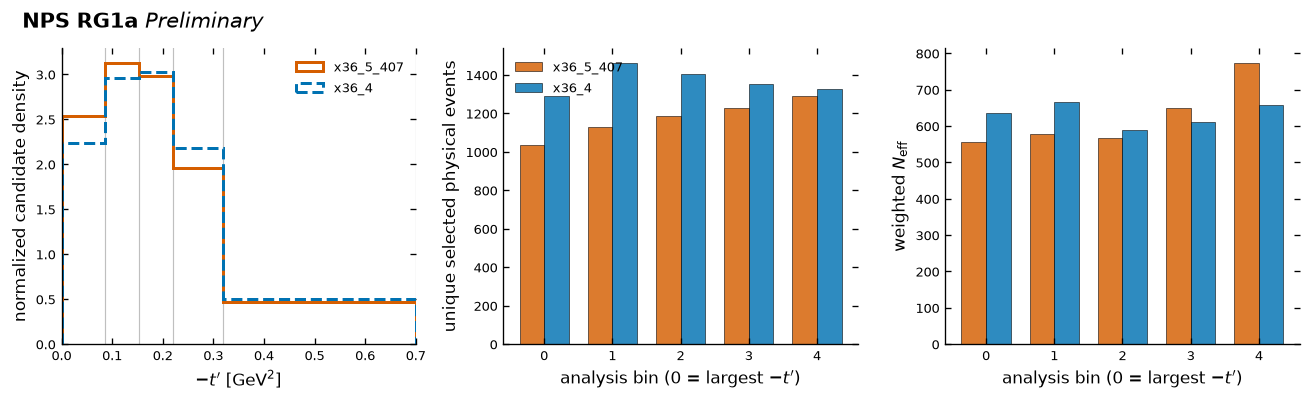

In [43]:
raw_counts={}
for k in KIN_ORDER:
    f=phase[k].loc[selection_masks[k]["individual_final"]].copy()
    f["tprime_bin"]=np.searchsorted(tprime_edges,f.tprime,side="right")-1
    counts=(f.drop_duplicates(["run_number","event_id","tprime_bin"]).groupby("tprime_bin").size()
              .reindex(range(5),fill_value=0))
    raw_counts[k]=counts.to_numpy()
fig,axes=plt.subplots(1,3,figsize=(11,3.35))
positive_edges=-tprime_edges[::-1]
for k,ls in zip(KIN_ORDER,["-","--"]):
    v=-phase[k].loc[selection_masks[k]["individual_final"],"tprime"].to_numpy()
    axes[0].hist(v,bins=positive_edges,density=True,histtype="step",lw=1.8,color=COLORS[k],ls=ls,label=KIN_SHORT[k])
for edge in positive_edges: axes[0].axvline(edge,color=".75",lw=.7,zorder=0)
axes[0].set(xlabel=r"$-t'$ [GeV$^2$]",ylabel="normalized candidate density",xlim=(0,.70)); axes[0].legend(frameon=False)
x=np.arange(5); width=.36
for off,k in zip([-width/2,width/2],KIN_ORDER):
    axes[1].bar(x+off,raw_counts[k],width,color=COLORS[k],alpha=.82,edgecolor="black",linewidth=.4,label=KIN_SHORT[k])
    axes[2].bar(x+off,bin_stats[k].sort_values("tprime_bin").effective_entries,width,color=COLORS[k],alpha=.82,edgecolor="black",linewidth=.4)
axes[1].set(xlabel="analysis bin (0 = largest $-t'$)",ylabel="unique selected physical events",xticks=x); axes[1].legend(frameon=False)
axes[2].set(xlabel="analysis bin (0 = largest $-t'$)",ylabel=r"weighted $N_{\rm eff}$",xticks=x)
for ax in axes: ax.spines[["top","right"]].set_visible(False)
preliminary(axes[2]); fig.tight_layout()
export_figure(fig,"03_tprime_binning_occupancy","Exact t-prime bins, unique selected-event occupancy, and weighted effective entries")


## Extracted U, LT, and TT responses

Open markers are individual fits; filled markers are the simultaneous joint fit. Horizontal
bars span physical bin boundaries; small horizontal offsets separate markers for display
only. Statistical bars follow the stored release rule: basic 16–84% intervals where flagged,
otherwise symmetric delta68 radii. Joint translucent boxes are the separate fully correlated
2.397% target-divisor scale systematic. No individual systematic was released, so none is
invented. Points are not connected.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


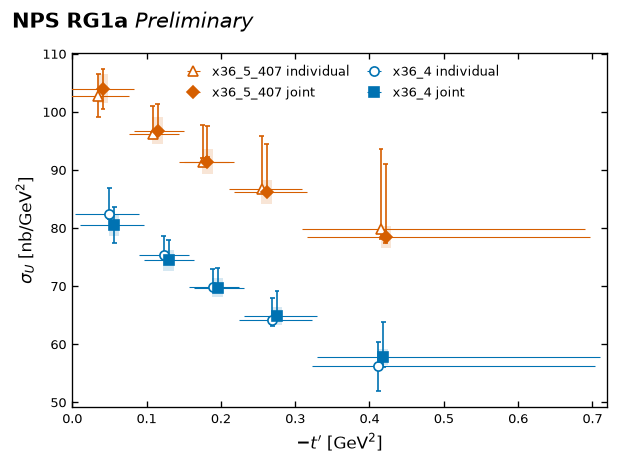

In [44]:
def interval_bounds(value,delta,lower,upper,use_basic):
    value=np.asarray(value,float); delta=np.asarray(delta,float); flag=np.asarray(use_basic,bool)
    low=np.where(flag,np.asarray(lower,float),value-delta)
    high=np.where(flag,np.asarray(upper,float),value+delta)
    if np.any(high<low) or not np.isfinite(np.vstack([low,high])).all(): raise ValueError("Bad interval")
    return low,high

def response_series(component):
    out=[]
    for k in KIN_ORDER:
        a=individual[k].sort_values("tprime_bin")
        d=individual_residual[k].query("component == @component").sort_values("tprime_bin")
        out.append({"kind":"Individual","kin":k,"x":-a.response_weighted_tprime.to_numpy(),
          "y":a[f"sigma_{component}"].to_numpy(),
          "bounds":interval_bounds(a[f"sigma_{component}"],a[f"{component}_delta68_stat"],
                                   d.basic_interval_lower,d.basic_interval_upper,d.use_basic_interval),
          "systematic":None})
        a=joint.query("kinematic == @k and component == @component").sort_values("truth_block")
        names=[f"{k}:{component}(bin{i})" for i in range(5)]
        d=joint_residual.set_index("quantity").loc[names]
        out.append({"kind":"Joint","kin":k,"x":-a.response_weighted_tprime.to_numpy(),"y":a.value.to_numpy(),
          "bounds":interval_bounds(a.value,a.delta68_stat,a.basic_interval_lower,a.basic_interval_upper,d.use_basic_interval),
          "systematic":a.target_systematic.to_numpy()})
    return out

def draw_interval(ax,x,low,high,color):
    ax.vlines(x,low,high,color=color,lw=1,zorder=2)
    cap=.0032
    ax.hlines(low,x-cap,x+cap,color=color,lw=1,zorder=2)
    ax.hlines(high,x-cap,x+cap,color=color,lw=1,zorder=2)

def plot_response(component,stem):
    fig,ax=plt.subplots(figsize=(5.2,3.9)); offsets=[-.010,-.0035,.0035,.010]
    joint_marker={"KinC_x36_5_407":"D","KinC_x36_4":"s"}
    for off,item in zip(offsets,response_series(component)):
        x=item["x"]; xd=x+off; lo=-tprime_edges[1:]; hi=-tprime_edges[:-1]
        xerr=np.vstack([x-lo,hi-x]); low,high=item["bounds"]
        marker=MARKERS[item["kin"]] if item["kind"]=="Individual" else joint_marker[item["kin"]]
        fill="white" if item["kind"]=="Individual" else COLORS[item["kin"]]
        if item["systematic"] is not None:
            for xp,yp,sy in zip(xd,item["y"],item["systematic"]):
                ax.add_patch(Rectangle((xp-.007,yp-sy),.014,2*sy,facecolor=COLORS[item["kin"]],edgecolor="none",alpha=.16,zorder=1))
        draw_interval(ax,xd,low,high,COLORS[item["kin"]])
        ax.errorbar(xd,item["y"],xerr=xerr,fmt=marker,ls="none",color=COLORS[item["kin"]],
          markerfacecolor=fill,markeredgecolor=COLORS[item["kin"]],markeredgewidth=1,capsize=0,elinewidth=.65,
          label=f"{KIN_SHORT[item['kin']]} {item['kind'].lower()}",zorder=3)
    if component!="U":
        ax.axhline(0,color=".55",lw=.8,zorder=0)
        ax.set_ylim(top=1)
    ax.set(xlabel=r"$-t'$ [GeV$^2$]",ylabel=rf"{COMPONENT_LABEL[component]} [nb/GeV$^2$]",xlim=(0,.72))
    ax.legend(ncol=2,frameon=False,loc="upper center",handletextpad=.4,columnspacing=.8); preliminary(ax); fig.tight_layout()
    export_figure(fig,stem,f"{component} response: individual x36_4/x36_5_407 and joint fit with released intervals")

plot_response("U","04_sigma_U_individual_joint")


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


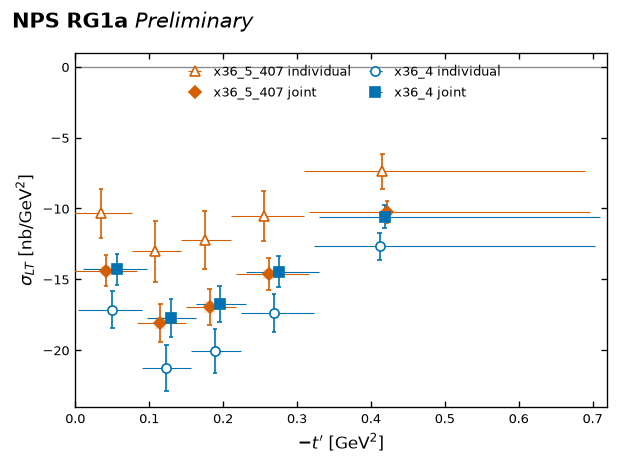

In [45]:
plot_response("LT","05_sigma_LT_individual_joint")


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


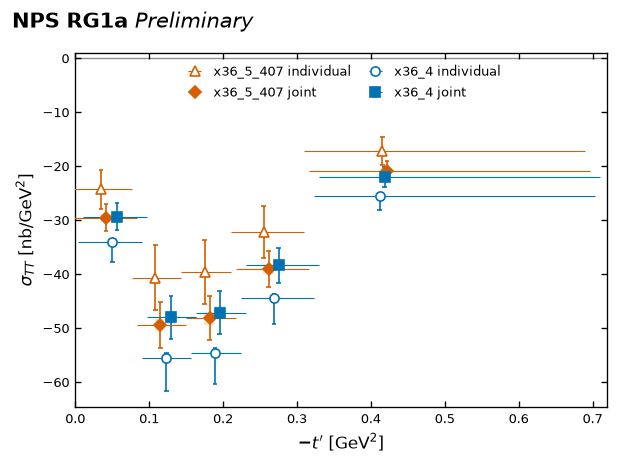

In [46]:
plot_response("TT","06_sigma_TT_individual_joint")


## Stored T/L separation

Nominal massless-electron central kinematics give $\epsilon=0.711500506617$ for
x36_5_407 and 0.516318176159 for x36_4. In each matched truth bin, the two joint
$\sigma_U$ values are transformed exactly through $\sigma_U=\sigma_T+\epsilon\sigma_L$;
the same transformation is applied to all 500 joint refit toys. Nominal-epsilon and
kinematic-centering/model uncertainties are not propagated. The target scale remains separate.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


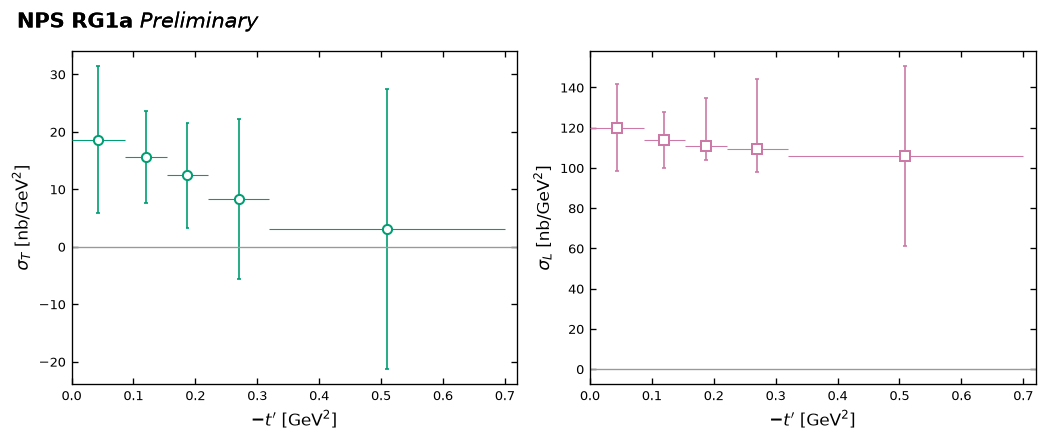

In [47]:
fig,axes=plt.subplots(1,2,figsize=(8.8,3.7),sharex=True)
for ax,c,color,marker in zip(axes,["T","L"],["#009E73","#CC79A7"],["o","s"]):
    a=lt.query("component == @c").sort_values("tprime_bin"); x=a.tprime_center.to_numpy(); y=a.central.to_numpy()
    low,high=interval_bounds(y,a.delta68_stat,a.basic_interval_lower,a.basic_interval_upper,a.use_basic_interval)
    lo=-tprime_edges[1:]; hi=-tprime_edges[:-1]; xerr=np.vstack([x-lo,hi-x])
    for xp,yp,sy in zip(x,y,a.target_scale_systematic):
        ax.add_patch(Rectangle((xp-.008,yp-sy),.016,2*sy,facecolor=color,edgecolor="none",alpha=.18,zorder=1))
    draw_interval(ax,x,low,high,color)
    ax.errorbar(x,y,xerr=xerr,fmt=marker,ls="none",color=color,markerfacecolor="white",
                markeredgewidth=1.2,capsize=0,elinewidth=.65,zorder=3)
    ax.axhline(0,color=".6",lw=.8); ax.set(xlabel=r"$-t'$ [GeV$^2$]",ylabel=rf"$\sigma_{c}$ [nb/GeV$^2$]",xlim=(0,.72))
    preliminary(ax)
fig.tight_layout()
export_figure(fig,"07_LT_separated_summary","Joint toy-calibrated transverse and longitudinal separated responses")


<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/scratch/singhav/ipykernel_3030195/2405688094.py:21: SyntaxWarning: invalid escape sequence '\e'
  axes[5].legend(handles=[Line2D([0],[0],color=COLORS["KinC_x36_5_407"],lw=2,label="x36_5_407 ($\epsilon=0.712$)"),
/scratch/singhav/ipykernel_3030195/2405688094.py:22: SyntaxWarning: invalid escape sequence '\e'
  Line2D([0],[0],color=COLORS["KinC_x36_4"],lw=2,label="x36_4 ($\epsilon=0.516$)"),
/scratch/singhav/ipykernel_3030195/2405688094.py:25: SyntaxWarning: invalid escape sequence '\s'
  Line2D([0],[0],marker="s",color=".25",ls="none",markerfacecolor=".25",label="joint $\sigma_U$ input

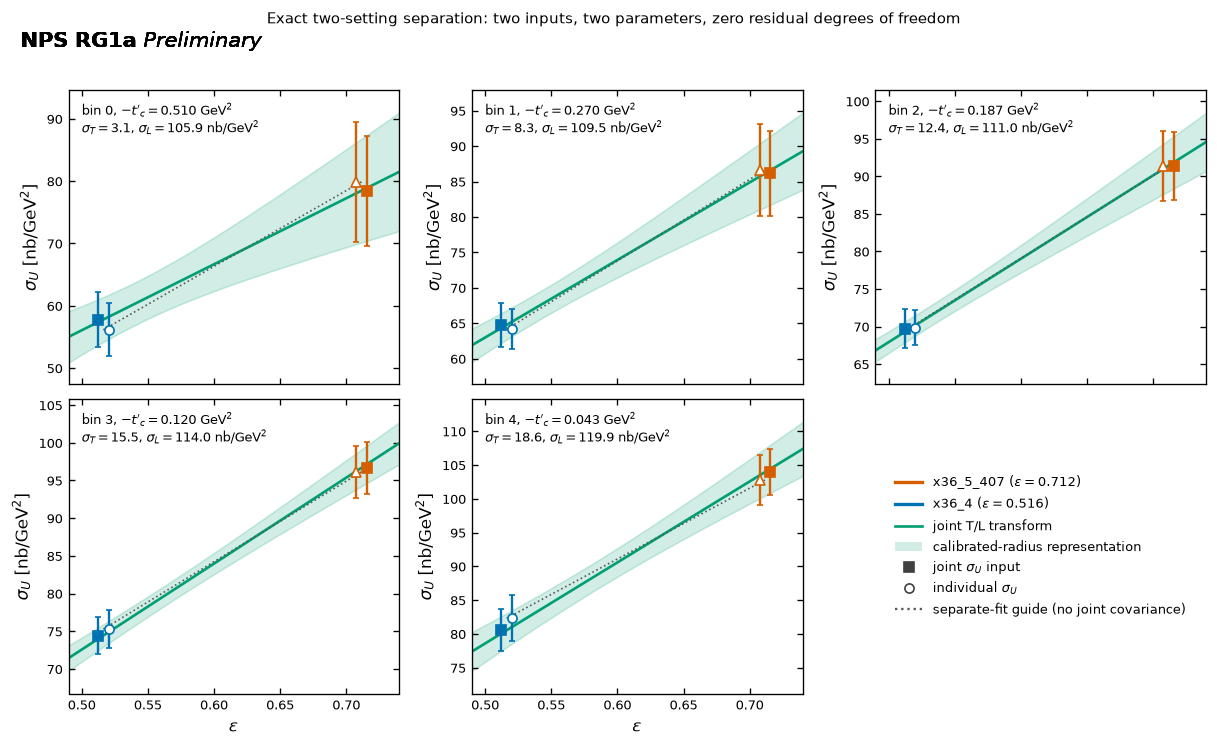

In [48]:
fig,axes=plt.subplots(2,3,figsize=(10.3,6.2),sharex=True); axes=axes.ravel()
eg=np.linspace(.48,.75,160)
for b in range(5):
    ax=axes[b]; tr=lt[(lt.component=="T")&(lt.tprime_bin==b)].iloc[0]; lr=lt[(lt.component=="L")&(lt.tprime_bin==b)].iloc[0]
    T,L=float(tr.central),float(lr.central); cov=lt_cov68[np.ix_([b,5+b],[b,5+b])]
    design=np.column_stack([np.ones_like(eg),eg]); band=np.sqrt(np.maximum(np.einsum("ij,jk,ik->i",design,cov,design),0))
    fit=T+eg*L; ax.fill_between(eg,fit-band,fit+band,color="#009E73",alpha=.18); ax.plot(eg,fit,color="#009E73",lw=1.6)
    ip=[]
    for k,shift in zip(KIN_ORDER,[.004,-.004]):
        e=epsilons[k]; j=joint[(joint.kinematic==k)&(joint.component=="U")&(joint.truth_block==b)].iloc[0]
        a=individual[k].query("tprime_bin == @b").iloc[0]
        ax.errorbar(e+shift,j.value,yerr=j.delta68_stat,fmt="s",color=COLORS[k],markerfacecolor=COLORS[k],capsize=2,zorder=4)
        ax.errorbar(e-shift,a.sigma_U,yerr=a.U_delta68_stat,fmt=MARKERS[k],color=COLORS[k],markerfacecolor="white",capsize=2,zorder=4)
        ip.append((e,a.sigma_U))
    ip.sort(); ax.plot([p[0] for p in ip],[p[1] for p in ip],color=".35",ls=":",lw=1)
    ax.text(.04,.96,rf"bin {b}, $-t'_c={tr.tprime_center:.3f}$ GeV$^2$"+f"\n"+rf"$\sigma_T={T:.1f}$, $\sigma_L={L:.1f}$ nb/GeV$^2$",
            transform=ax.transAxes,va="top",fontsize=7.5)
    ax.set_ylabel(r"$\sigma_U$ [nb/GeV$^2$]"); ax.set_xlim(.49,.74); preliminary(ax)
for ax in axes[3:5]: ax.set_xlabel(r"$\epsilon$")
axes[5].axis("off")
axes[5].legend(handles=[Line2D([0],[0],color=COLORS["KinC_x36_5_407"],lw=2,label="x36_5_407 ($\epsilon=0.712$)"),
 Line2D([0],[0],color=COLORS["KinC_x36_4"],lw=2,label="x36_4 ($\epsilon=0.516$)"),
 Line2D([0],[0],color="#009E73",lw=1.6,label="joint T/L transform"),
 Rectangle((0,0),1,1,facecolor="#009E73",alpha=.18,label="calibrated-radius representation"),
 Line2D([0],[0],marker="s",color=".25",ls="none",markerfacecolor=".25",label="joint $\sigma_U$ input"),
 Line2D([0],[0],marker="o",color=".25",ls="none",markerfacecolor="white",label="individual $\sigma_U$"),
 Line2D([0],[0],color=".35",ls=":",label="separate-fit guide (no joint covariance)")],
 loc="center",frameon=False,fontsize=8)
fig.text(.5,.995,"Exact two-setting separation: two inputs, two parameters, zero residual degrees of freedom",ha="center",va="top",fontsize=9)
fig.tight_layout(rect=(0,0,1,.97))
export_figure(fig,"08_rosenbluth_two_epsilon","Per-bin sigma_U versus epsilon with exact joint T/L lines, bands, and individual inputs")


## Fit quality and statistical diagnostics

Closure uses the frozen calibrated central campaign arrays, not an older generic report.
Pulls are $(y-\mu)/\sqrt{V_{\rm data}+V_{\rm MC}}$. The nominal chi-square probability is
descriptive only because positivity is active and the fit is boundary-constrained. The
accepted toys supply the published calibration; failed attempts are available only in aggregate.


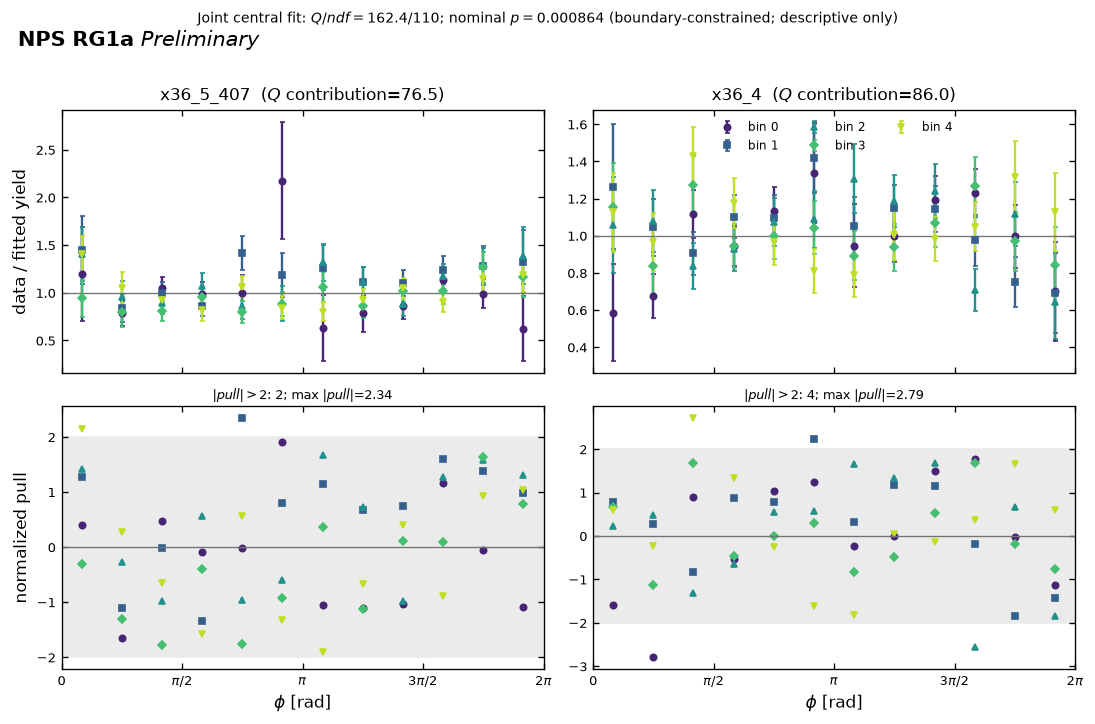

In [49]:
Q=float(np.sum(row_map.pull**2)); ndf=len(row_map)-int(central_json["rank"]); p_nominal=float(chi2_distribution.sf(Q,ndf))
np.testing.assert_allclose(Q,central_json["objective"],rtol=2e-12,atol=2e-12)
fig,axes=plt.subplots(2,2,figsize=(9.2,6),sharex="col")
bin_colors=mpl.colormaps["viridis"](np.linspace(.1,.9,5)); bin_markers=["o","s","^","D","v"]
for col,k in enumerate(KIN_ORDER):
    s=row_map[row_map.kinematic==k]
    for b,(color,marker) in enumerate(zip(bin_colors,bin_markers)):
        a=s[s.it==b]
        axes[0,col].errorbar(a.phi_center,a.ratio,yerr=a.ratio_error,fmt=marker,ls="none",ms=3.8,color=color,capsize=1.5,label=f"bin {b}")
        axes[1,col].plot(a.phi_center,a.pull,marker=marker,ls="none",ms=3.8,color=color)
    axes[0,col].axhline(1,color=".45",lw=.8); axes[1,col].axhline(0,color=".45",lw=.8); axes[1,col].axhspan(-2,2,color=".92",zorder=0)
    qs=float(np.sum(s.pull**2)); out=int(np.sum(np.abs(s.pull)>2))
    axes[0,col].set_title(f"{KIN_SHORT[k]}  ($Q$ contribution={qs:.1f})")
    axes[1,col].set_title(rf"$|pull|>2$: {out}; max $|pull|$={np.max(np.abs(s.pull)):.2f}",fontsize=7.5,pad=4)
    axes[1,col].set(xlabel=r"$\phi$ [rad]",xlim=(0,2*np.pi),xticks=[0,np.pi/2,np.pi,3*np.pi/2,2*np.pi],
      xticklabels=["0",r"$\pi/2$",r"$\pi$",r"$3\pi/2$",r"$2\pi$"])
axes[0,0].set_ylabel("data / fitted yield"); axes[1,0].set_ylabel("normalized pull")
axes[0,1].legend(ncol=3,frameon=False,fontsize=7,loc="upper center")
fig.suptitle(rf"Joint central fit: $Q/ndf={Q:.1f}/{ndf}$; nominal $p={p_nominal:.3g}$ (boundary-constrained; descriptive only)",
             fontsize=8.5,y=.995)
preliminary(axes[0,1]); fig.tight_layout(rect=(0,0,1,.955))
export_figure(fig,"09_joint_fit_closure_pulls","Frozen joint yield ratios and finite-MC normalized pulls versus phi")

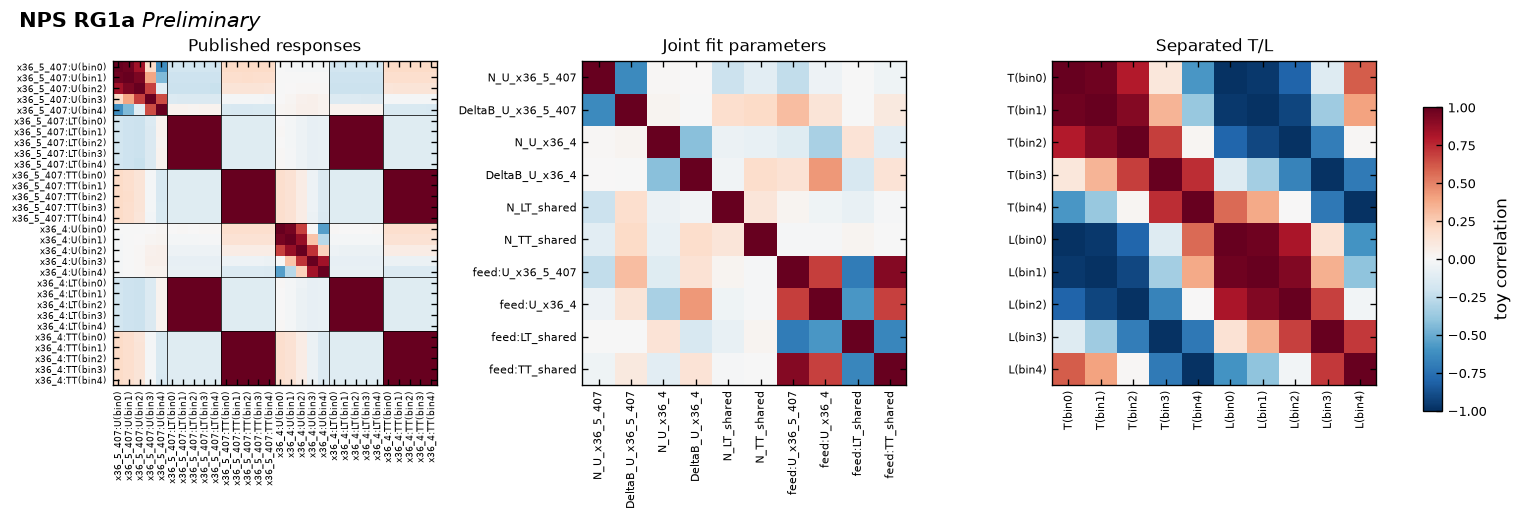

In [50]:
fig,axes=plt.subplots(1,3,figsize=(13,4.6))
items=[(published_corr,published_labels,"Published responses",[x.replace("KinC_","") for x in published_labels]),
       (parameter_corr,parameter_labels,"Joint fit parameters",[x.replace("KinC_","").replace("feedin_tprime_below_","feed:") for x in parameter_labels]),
       (lt_corr,lt_labels,"Separated T/L",lt_labels)]
for ax,(matrix,labels,title,short) in zip(axes,items):
    im=ax.imshow(matrix,vmin=-1,vmax=1,cmap="RdBu_r",interpolation="nearest"); ax.set_title(title)
    size=5.2 if len(labels)>15 else 6.5
    ax.set_xticks(range(len(labels)),short,rotation=90,fontsize=size); ax.set_yticks(range(len(labels)),short,fontsize=size)
    if len(labels)==30:
        for edge in [4.5,9.5,14.5,19.5,24.5]: ax.axhline(edge,color="black",lw=.45); ax.axvline(edge,color="black",lw=.45)
fig.subplots_adjust(left=.08,right=.89,bottom=.29,top=.89,wspace=.45)
cax=fig.add_axes([.92,.25,.012,.55])
fig.colorbar(im,cax=cax,label="toy correlation")
preliminary(axes[-1])
export_figure(fig,"10_correlation_matrices","Toy correlations for joint responses, fitted parameters, and separated T/L quantities")

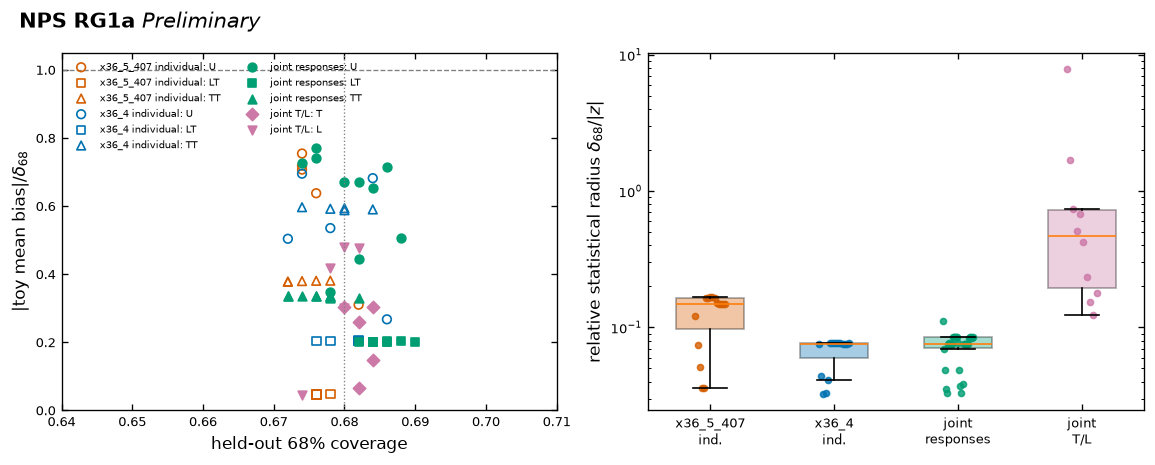

In [51]:
parts=[]
for k in KIN_ORDER:
    f=individual_residual[k].copy(); f["group"]=f"{KIN_SHORT[k]} individual"; f["relative_delta"]=f.delta68/np.maximum(f.central.abs(),1e-12)
    parts.append(f[["quantity","group","component","cross_validated_coverage68","abs_bias_over_delta68","relative_delta"]])
f=joint_residual.copy(); f["group"]="joint responses"; f["component"]=f.quantity.str.extract(r":(U|LT|TT)\(")
f["abs_bias_over_delta68"]=f.toy_mean_bias.abs()/f.delta68; f["relative_delta"]=f.delta68/np.maximum(f.central.abs(),1e-12)
parts.append(f[["quantity","group","component","cross_validated_coverage68","abs_bias_over_delta68","relative_delta"]])
f=lt.copy(); f["group"]="joint T/L"; f["abs_bias_over_delta68"]=f.toy_mean_bias.abs()/f.delta68_stat
f["relative_delta"]=f.delta68_stat/np.maximum(f.central.abs(),1e-12)
parts.append(f[["quantity","group","component","cross_validated_coverage68","abs_bias_over_delta68","relative_delta"]])
calibration=pd.concat(parts,ignore_index=True)
fig,axes=plt.subplots(1,2,figsize=(9.7,3.9))
gc={"x36_5_407 individual":COLORS["KinC_x36_5_407"],"x36_4 individual":COLORS["KinC_x36_4"],
    "joint responses":"#009E73","joint T/L":"#CC79A7"}; cm={"U":"o","LT":"s","TT":"^","T":"D","L":"v"}
for group,g in calibration.groupby("group",sort=False):
    for comp,a in g.groupby("component",sort=False):
        axes[0].scatter(a.cross_validated_coverage68,a.abs_bias_over_delta68,color=gc[group],marker=cm[comp],s=27,
          facecolors="none" if "individual" in group else gc[group],label=f"{group}: {comp}")
axes[0].axvline(.68,color=".5",lw=.8,ls=":"); axes[0].axhline(1,color=".5",lw=.8,ls="--")
axes[0].set(xlabel="held-out 68% coverage",ylabel=r"$|$toy mean bias$|/\delta_{68}$",xlim=(.64,.71),ylim=(0,1.05))
groups=list(gc); vals=[calibration.loc[calibration.group==g,"relative_delta"].to_numpy() for g in groups]
bp=axes[1].boxplot(vals,tick_labels=[g.replace(" individual","\nind.").replace("joint ","joint\n") for g in groups],
                   showfliers=False,patch_artist=True,widths=.55)
for patch,g in zip(bp["boxes"],groups): patch.set_facecolor(gc[g]); patch.set_alpha(.35)
for i,(g,v) in enumerate(zip(groups,vals),1): axes[1].scatter(i+np.linspace(-.12,.12,len(v)),v,s=13,color=gc[g],alpha=.8)
axes[1].set_yscale("log"); axes[1].set_ylabel(r"relative statistical radius $\delta_{68}/|z|$")
axes[0].legend(ncol=2,fontsize=6.2,frameon=False,loc="upper left"); preliminary(axes[1]); fig.tight_layout()
export_figure(fig,"11_toy_calibration_diagnostics","Held-out coverage versus toy bias and relative calibrated statistical precision")


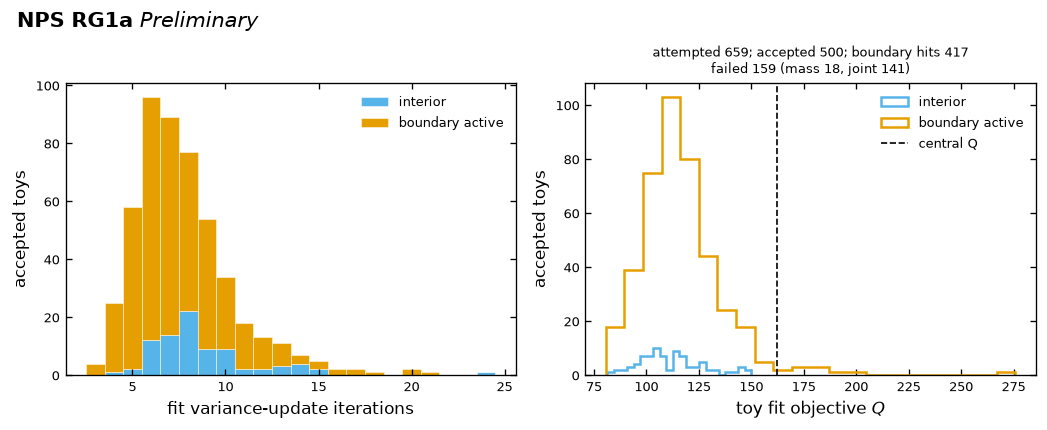

In [52]:
fig,axes=plt.subplots(1,2,figsize=(8.8,3.6)); boundary=toys["boundary_hit"]
bins=np.arange(toys["iterations"].min()-.5,toys["iterations"].max()+1.5)
axes[0].hist([toys["iterations"][~boundary],toys["iterations"][boundary]],bins=bins,stacked=True,
 color=["#56B4E9","#E69F00"],edgecolor="white",linewidth=.3,label=["interior","boundary active"])
axes[0].set(xlabel="fit variance-update iterations",ylabel="accepted toys"); axes[0].legend(frameon=False)
axes[1].hist(toys["q"][~boundary],bins=22,histtype="step",lw=1.5,color="#56B4E9",label="interior")
axes[1].hist(toys["q"][boundary],bins=22,histtype="step",lw=1.5,color="#E69F00",label="boundary active")
axes[1].axvline(central_json["objective"],color="black",lw=1,ls="--",label="central Q")
axes[1].set(xlabel="toy fit objective $Q$",ylabel="accepted toys"); axes[1].legend(frameon=False)
s=joint_summary["toy_summary"]
axes[1].set_title(f"attempted {s['attempted']}; accepted {s['accepted']}; boundary hits {s['boundary_hits']}\n"
                  f"failed {s['fit_failures']} (mass {s['mass_fit_failures']}, joint {s['joint_M0_failures']})",
                  fontsize=7.5,pad=6)
preliminary(axes[0])
fig.tight_layout(rect=(0,0,1,.94))
export_figure(fig,"12_joint_toy_convergence","Accepted joint-toy iteration/objective distributions with boundary and failure summary")

## Total angular cross section overlays

For each accepted $t'$ bin, the stored responses are combined with the nominal setting-specific
$\epsilon$ using the extraction convention

$$
\frac{d^2\sigma}{dt'\,d\phi}=\frac{1}{2\pi}\left[\sigma_U+
\sqrt{2\epsilon(1+\epsilon)}\,\sigma_{LT}\cos\phi+
\epsilon\,\sigma_{TT}\cos(2\phi)\right].
$$

The shaded intervals propagate the released calibrated response-covariance representation. The
joint-fit panel additionally shows the released fully correlated target-scale uncertainty as
thin dotted envelopes. Curves are response reconstructions, not refits to binned points.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


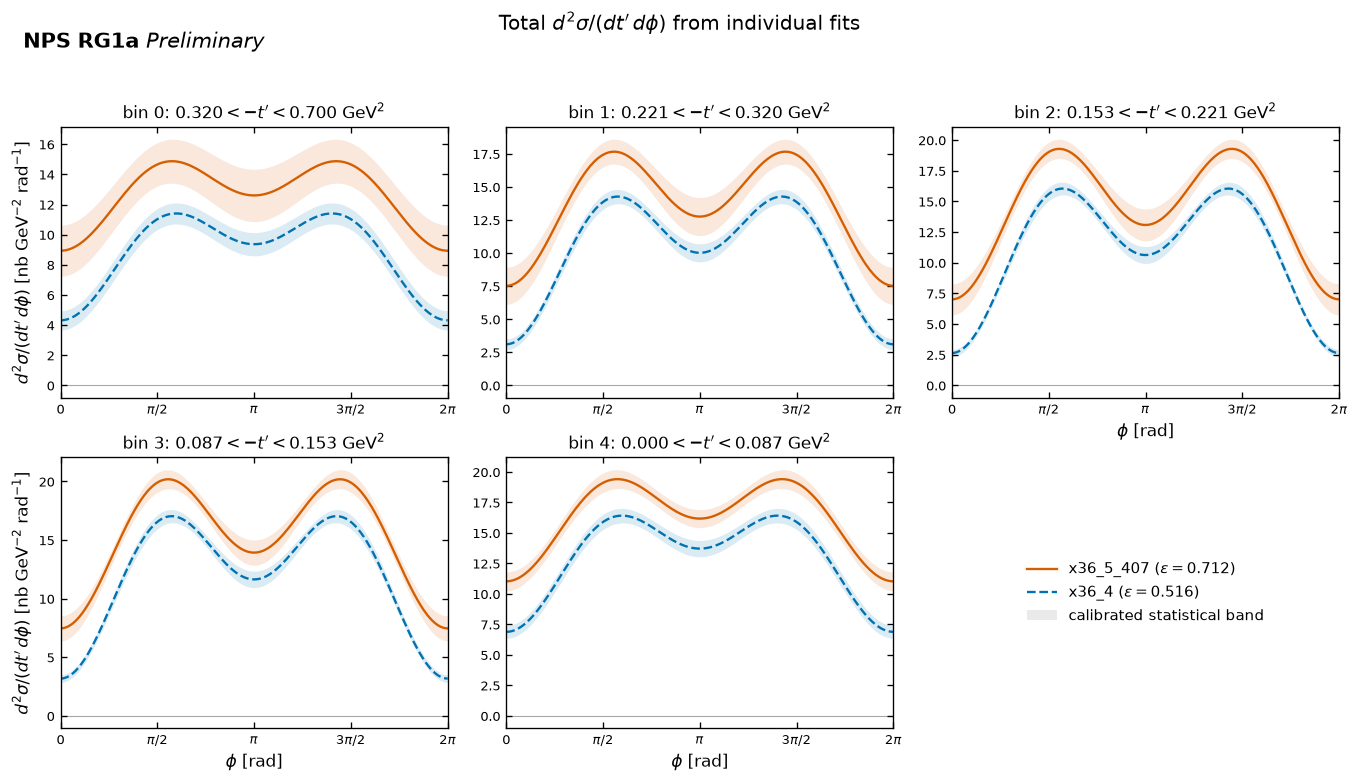

In [53]:
PHI_GRID=np.linspace(0,2*np.pi,361)
LINESTYLE={"KinC_x36_5_407":"-","KinC_x36_4":"--"}

def angular_basis(epsilon,phi=PHI_GRID):
    return np.vstack([np.ones_like(phi),
      np.sqrt(2*epsilon*(1+epsilon))*np.cos(phi),epsilon*np.cos(2*phi)])/(2*np.pi)

def angular_curve_band(coefficients,covariance,indices,epsilon):
    basis=angular_basis(epsilon)
    y=np.asarray(coefficients,float)@basis
    sub=np.asarray(covariance,float)[np.ix_(indices,indices)]
    delta=np.sqrt(np.maximum(0,np.einsum("in,ij,jn->n",basis,sub,basis)))
    return y,delta

def format_angular_axes(axes):
    for b,ax in enumerate(axes.flat[:5]):
        lo,hi=max(0.0,-tprime_edges[b+1]),max(0.0,-tprime_edges[b])
        ax.set_title(rf"bin {b}: ${lo:.3f} < -t' < {hi:.3f}$ GeV$^2$",pad=5)
        ax.set(xlim=(0,2*np.pi),xticks=[0,np.pi/2,np.pi,3*np.pi/2,2*np.pi],
               xticklabels=["0",r"$\pi/2$",r"$\pi$",r"$3\pi/2$",r"$2\pi$"])
        if b in [0,3]: ax.set_ylabel(r"$d^2\sigma/(dt'\,d\phi)$ [nb GeV$^{-2}$ rad$^{-1}$]")
        if b>=2: ax.set_xlabel(r"$\phi$ [rad]")
        ax.axhline(0,color=".65",lw=.65,zorder=0)
    axes.flat[5].axis("off")

fig,axes=plt.subplots(2,3,figsize=(11.4,6.5))
for b,ax in enumerate(axes.flat[:5]):
    for k in KIN_ORDER:
        a=individual[k].set_index("tprime_bin").loc[b]
        coeff=[a.sigma_U,a.sigma_LT,a.sigma_TT]
        y,dy=angular_curve_band(coeff,individual_cov[k],[b,5+b,10+b],epsilons[k])
        ax.fill_between(PHI_GRID,y-dy,y+dy,color=COLORS[k],alpha=.14,lw=0)
        ax.plot(PHI_GRID,y,color=COLORS[k],ls=LINESTYLE[k])
format_angular_axes(axes)
handles=[Line2D([0],[0],color=COLORS[k],ls=LINESTYLE[k],label=rf"{KIN_SHORT[k]} ($\epsilon={epsilons[k]:.3f}$)") for k in KIN_ORDER]
handles.append(Rectangle((0,0),1,1,fc=".55",alpha=.18,ec="none",label="calibrated statistical band"))
axes.flat[5].legend(handles=handles,loc="center",frameon=False,fontsize=9)
fig.suptitle(r"Total $d^2\sigma/(dt'\,d\phi)$ from individual fits",fontsize=12,y=.995)
preliminary(axes.flat[2]); fig.tight_layout(rect=(0,0,1,.95))
export_figure(fig,"13_total_angular_cross_section_individual","All-bin setting overlay of total angular cross sections from individual fits")

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


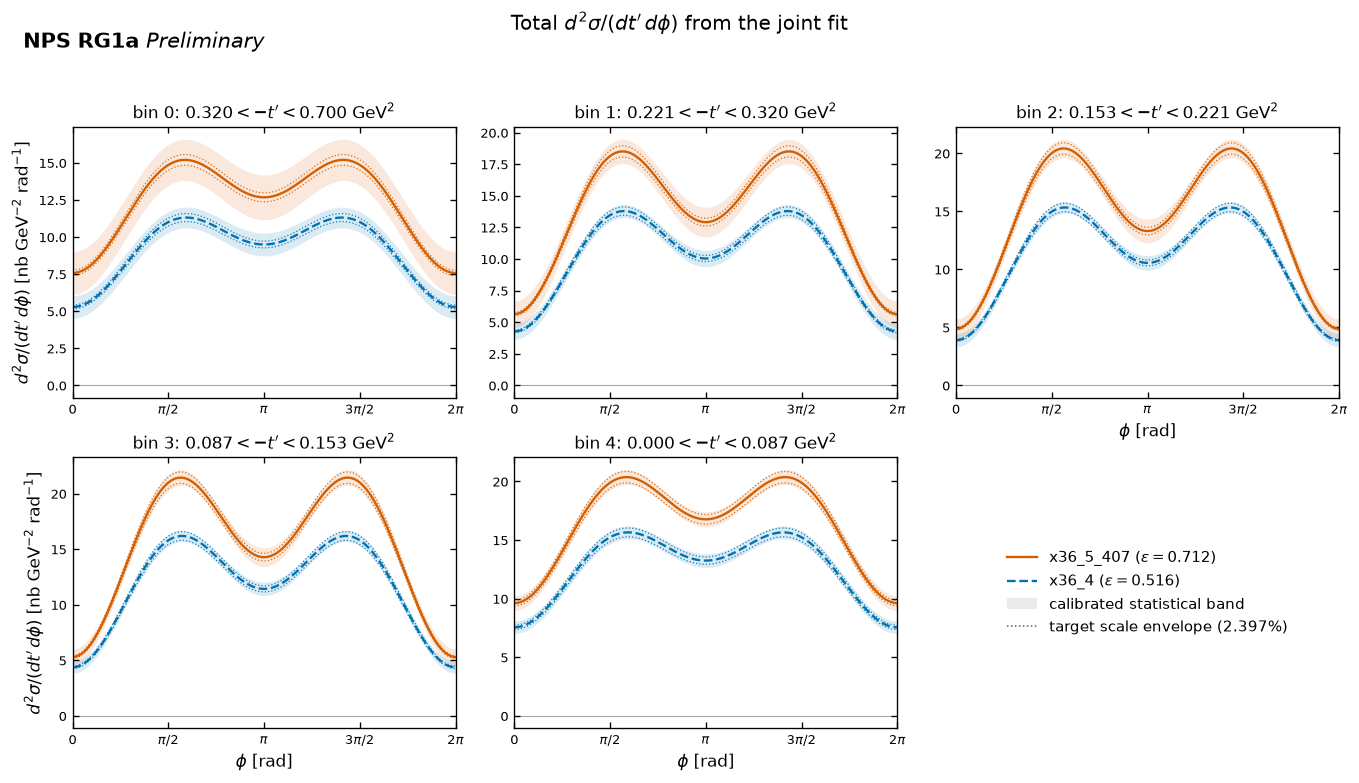

In [54]:
fig,axes=plt.subplots(2,3,figsize=(11.4,6.5))
joint_index={name:i for i,name in enumerate(joint_cov_labels)}
target_fraction=float((joint.target_systematic/joint.value.abs()).median())
for b,ax in enumerate(axes.flat[:5]):
    for k in KIN_ORDER:
        rows=joint[(joint.kinematic==k)&(joint.truth_block==b)].set_index("component")
        names=[f"{k}:{c}(bin{b})" for c in ["U","LT","TT"]]
        coeff=[rows.loc[c,"value"] for c in ["U","LT","TT"]]
        idx=[joint_index[n] for n in names]
        y,dy=angular_curve_band(coeff,joint_cov68,idx,epsilons[k])
        ax.fill_between(PHI_GRID,y-dy,y+dy,color=COLORS[k],alpha=.14,lw=0)
        ax.plot(PHI_GRID,y,color=COLORS[k],ls=LINESTYLE[k])
        ax.plot(PHI_GRID,y*(1+target_fraction),color=COLORS[k],ls=":",lw=.75,alpha=.9)
        ax.plot(PHI_GRID,y*(1-target_fraction),color=COLORS[k],ls=":",lw=.75,alpha=.9)
format_angular_axes(axes)
handles=[Line2D([0],[0],color=COLORS[k],ls=LINESTYLE[k],label=rf"{KIN_SHORT[k]} ($\epsilon={epsilons[k]:.3f}$)") for k in KIN_ORDER]
handles.extend([Rectangle((0,0),1,1,fc=".55",alpha=.18,ec="none",label="calibrated statistical band"),
                Line2D([0],[0],color=".35",ls=":",lw=.9,label=f"target scale envelope ({100*target_fraction:.3f}%)")])
axes.flat[5].legend(handles=handles,loc="center",frameon=False,fontsize=9)
fig.suptitle(r"Total $d^2\sigma/(dt'\,d\phi)$ from the joint fit",fontsize=12,y=.995)
preliminary(axes.flat[2]); fig.tight_layout(rect=(0,0,1,.95))
export_figure(fig,"14_total_angular_cross_section_joint","All-bin setting overlay of total angular cross sections from the joint fit")

## Export and immutability validation

Every canvas is exported once as vector PDF and once as a 320-dpi PNG. The checks below
verify the intended count, nonempty format signatures, readable PNG dimensions, and unchanged
input hashes after plotting.


In [55]:
from PIL import Image
figure_manifest=pd.DataFrame(FIGURE_RECORDS)
assert len(figure_manifest)==14 and figure_manifest.figure.is_unique
for r in FIGURE_RECORDS:
    pdf=REPO/r["PDF"]; png=REPO/r["PNG"]
    assert pdf.is_file() and pdf.stat().st_size>1000 and pdf.read_bytes()[:4]==b"%PDF"
    assert png.is_file() and png.stat().st_size>1000
    with Image.open(png) as im: im.verify()
    with Image.open(png) as im: assert im.width>=1200 and im.height>=900
changed=[rel for rel,(expected,_) in INPUTS.items() if sha256(REPO/rel)!=expected]
assert not changed,f"Read-only inputs changed: {changed}"
display(figure_manifest)
print(f"Validated {2*len(figure_manifest)} exports ({len(figure_manifest)} PDF + {len(figure_manifest)} PNG).")
print(f"Reverified {len(INPUTS)} input SHA-256 checksums after plotting: all unchanged.")

,figure,PDF,PNG,shows
0,01_phase_space_selection,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Data phase space before/after individual-windo...
1,02_phase_space_overlap,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Overlap of joint-selected x36_4 and x36_5_407 ...
2,03_tprime_binning_occupancy,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,"Exact t-prime bins, unique selected-event occu..."
3,04_sigma_U_individual_joint,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,U response: individual x36_4/x36_5_407 and joi...
4,05_sigma_LT_individual_joint,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,LT response: individual x36_4/x36_5_407 and jo...
5,06_sigma_TT_individual_joint,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,TT response: individual x36_4/x36_5_407 and jo...
6,07_LT_separated_summary,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Joint toy-calibrated transverse and longitudin...
7,08_rosenbluth_two_epsilon,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Per-bin sigma_U versus epsilon with exact join...
8,09_joint_fit_closure_pulls,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,Frozen joint yield ratios and finite-MC normal...
9,10_correlation_matrices,output/publication_figures/x36_4_x36_5_407_cal...,output/publication_figures/x36_4_x36_5_407_cal...,"Toy correlations for joint responses, fitted p..."


Validated 28 exports (14 PDF + 14 PNG).
Reverified 30 input SHA-256 checksums after plotting: all unchanged.


## Scientific scope and limitations

- Phase-space figures begin with combined physics trees, not detector-raw events. They show
  extraction selections, the exact accepted diamond, overlap, and binning, but not upstream
  detector/PID cut flow.
- Individual releases contain calibrated statistical intervals but no released systematic
  uncertainty. Their angular-overlay bands use the stored calibrated covariance representation.
  Only joint and T/L products expose the separate fully correlated 2.397% target scale; it is
  shown separately and never combined silently with statistics.
- The two-$\epsilon$ T/L transformation has two inputs and two parameters per bin, hence no
  residual degrees of freedom. Its band uses the stored
  $\mathrm{diag}(\delta_{68})R_{\rm toy}\mathrm{diag}(\delta_{68})$ representation;
  $\delta_{68}^2$ is not asserted to be a Gaussian variance.
- Nominal-$\epsilon$ uncertainty and kinematic-centering/model uncertainty from different
  response-weighted $t'$ values are unavailable and not propagated.
- The joint central fit is boundary-active. Its nominal chi-square p-value is descriptive;
  coverage claims come from the accepted physical-event toy campaign.
- Per-start histories for the calibrated campaign and detailed records for 159 failed toy
  attempts are not stored. Available iterations, boundary flags, aggregate failures,
  correlations, coverage, residuals, and pulls are shown without fabricating diagnostics.